# CE543: Intro to EQ Engr - Homework Assignment 5

## Problem 1

In [1]:
import numpy as np
import pandas as pd
from icecream import ic
import sympy as sy
from sympy.solvers import solve
from sympy import Symbol
import matplotlib.pyplot as plt

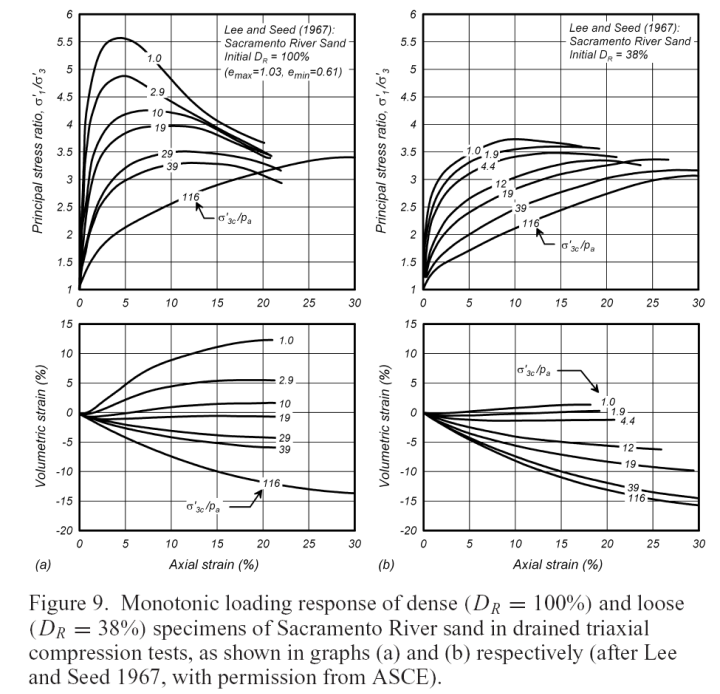

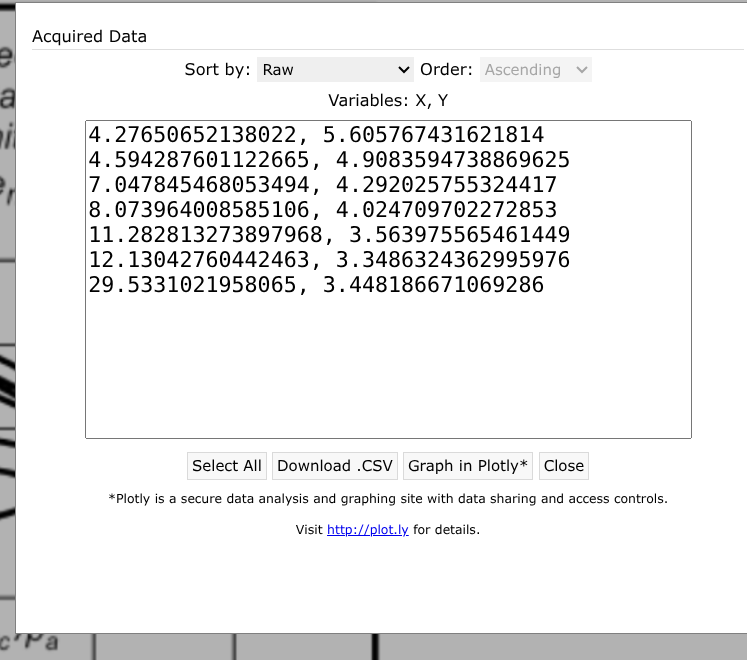

ic| cell_pressure_100/100: array([  1. ,   2.9,  10. ,  19. ,  29. ,  39. , 116. ])
ic| phi_values: array([44.18438515, 41.3774773 , 38.50928912, 36.86989765, 34.41738871,
                       32.336026  , 33.05573115])


array([44.18438515, 41.3774773 , 38.50928912, 36.86989765, 34.41738871,
       32.336026  , 33.05573115])

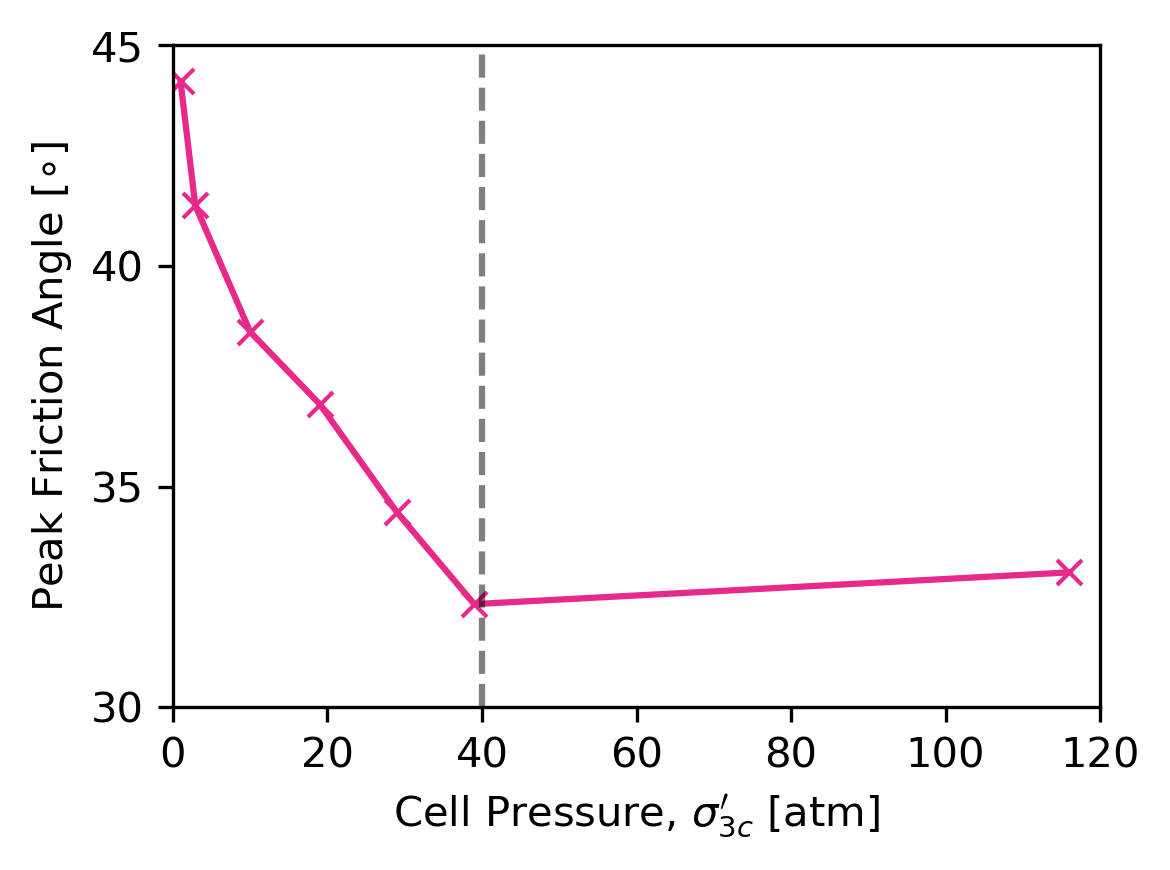

In [2]:
cell_pressure_100 = 100 * np.array([1, 2.9,10,19,29, 39,116]) # cell pressures
max_flow_number = np.array([5.6, 4.9, 4.3, 4.0, 3.6, 3.3, 3.4]) # max flow number for each cell pressure
phi = Symbol('phi')
phi_values = np.zeros(len(cell_pressure_100))
for index, N in enumerate(max_flow_number):
    phi_value = sy.deg(solve((((1+sy.sin(phi))/(1-sy.sin(phi)))-N), phi)[0]).evalf()
    phi_values[index] = phi_value

fig, ax = plt.subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.plot(cell_pressure_100/100, phi_values, 'x', color = '#e7298a', linestyle = '-')
ax.set_xlabel("Cell Pressure, $\\sigma_{3c}'$ [atm]")
ax.set_ylabel('Peak Friction Angle [$\\circ$]')
ax.vlines(40, 30, 45, color = 'black', linestyle = '--', alpha = 0.5)
ax.set_xlim(0, 120)
ax.set_ylim(30, 45)
ax.set_yticks(np.arange(30, 46, 5))

ic(cell_pressure_100/100)
ic(phi_values)

Coefficents: [-7.53620808e-05  9.15185456e-01  4.33119234e+00]


ic| radius: array([  230. ,   565.5,  1650. ,  2850. ,  3770. ,  4485. , 13920. ])
ic| center: array([  330. ,   855.5,  2650. ,  4750. ,  6670. ,  8385. , 25520. ])


(array([   0.,  500., 1000., 1500., 2000., 2500., 3000.]),
 [Text(0, 0.0, '0'),
  Text(0, 500.0, '500'),
  Text(0, 1000.0, '1000'),
  Text(0, 1500.0, '1500'),
  Text(0, 2000.0, '2000'),
  Text(0, 2500.0, '2500'),
  Text(0, 3000.0, '3000')])

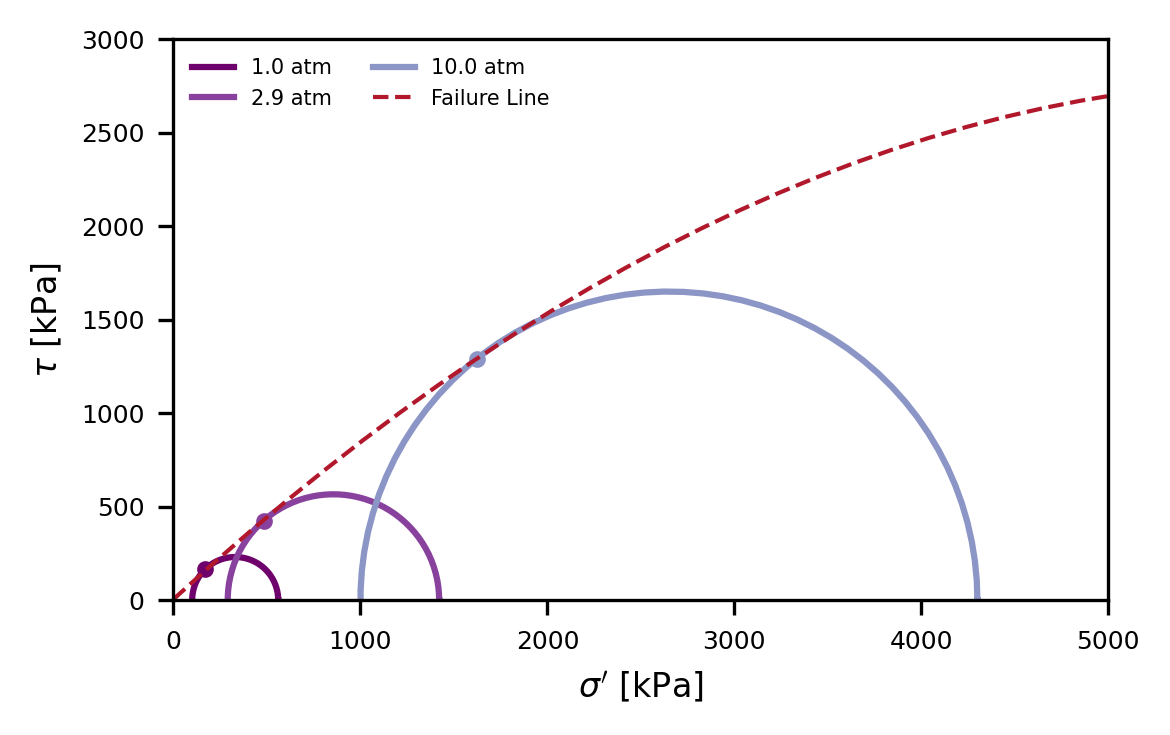

In [3]:
major_principal = np.multiply(cell_pressure_100, max_flow_number)
# ic(major_principal)
deviatoric = major_principal - cell_pressure_100
# ic(deviatoric)

radius = np.divide(deviatoric, 2)
center = np.add(cell_pressure_100, major_principal)/2

ic(radius)
ic(center)

radians = np.linspace(0, 2*np.pi, 100)
radians_matrix = np.zeros((7, 100))

for i in range(7):
    radians_matrix[i] = radians

mohr_sigma = np.array([center[i] + radius[i]*np.cos(angle) for i in range(7) for angle in radians]).reshape(7, 100)
mohr_tau = np.array([radius[i]*np.sin(angle) for i in range(7) for angle in radians]).reshape(7, 100)

sigma_ff = np.array([(center[i] )- (radius[i]*np.cos((np.pi/2)- (phi_values[i]*np.pi/180))) for i in range(7)])
tau_ff = np.array([sigma_ff[i]*np.tan((phi_values[i]*np.pi/180)) for i in range(7)])

# failure_points = np.array()
fit_line = np.polyfit([0, sigma_ff[0], sigma_ff[1], sigma_ff[2]], [0, tau_ff[0], tau_ff[1], tau_ff[2]], 2)
# fit_line = np.polyfit(sigma_ff, tau_ff, 2) # use this for all points
fir_coeff = np.poly1d(fit_line)
print(f"Coefficents: {fit_line}")

colors = ['#6e016b','#88419d', '#8c96c6', '#df65b0', '#e7298a', '#ce1256', '#91003f']

fig, ax = plt.subplots(figsize=(4,4), tight_layout=True, dpi=300)
for i in range(3): # change to 7 for all points
    ax.plot(mohr_sigma[i], mohr_tau[i], color = colors[i], linestyle = '-', label = f"{cell_pressure_100[i]/100} atm")
    ax.plot(sigma_ff[i], tau_ff[i], '.', color = colors[i])

ax.plot(np.linspace(0, 20000, 100), fir_coeff(np.linspace(0, 20000, 100)), color = '#b2182b', linestyle = '--', label = 'Failure Line', linewidth = 1)
ax.set_xlabel("$\\sigma'$ [kPa]", fontsize = 8)
ax.set_ylabel('$\\tau$ [kPa]', fontsize = 8)
ax.legend(frameon = False, fontsize = 5, ncol = 2, loc = 'upper left')
ax.set_aspect('equal')
# # use these for all points
# ax.set_ylim(0, 20000)
# ax.set_xlim(0, 40000)
# use these for 3 points
ax.set_ylim(0, 3000)
ax.set_xlim(0, 5000)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)

In [7]:
e0 = Symbol('e0')
e_max = 1.03
e_min = 0.61

e0_100 = e_min
e0_38 = solve(((e_max - e0)/(e_max - e_min))-0.38, e0)[0]
print(f"Void Ratio at DR = 100%: {e0_100}")
print(f"Void Ratio at DR = 38%: {e0_38}")

Void Ratio at DR = 100%: 0.61
Void Ratio at DR = 38%: 0.870399999999999


How to get $e_f$ from $\varepsilon_{vol}$? 

$$\Delta\varepsilon_v = -\frac{\Delta e}{1 + e_0} \Rightarrow \Delta e = -\varepsilon_v (1+ e_0)$$

$$ e_f = e_0 + \Delta e = e_0 -\varepsilon_v (1+ e_0) $$

or is it actually plus?

ic| strain_vol_100: array([ 0.12372014,  0.0556314 ,  0.01680887, -0.00648464, -0.04232082,
                           -0.0584471 , -0.13609215])
ic| strain_vol_38: array([ 0.0153169 ,  0.00390948, -0.01047332, -0.06085616, -0.09684689,
                          -0.14328945, -0.15535617])
ic| ef_100: array([0.80918942, 0.69956655, 0.63706229, 0.59955973, 0.54186348,
                   0.51590017, 0.39089164])
ic| ef_38: array([0.899048721447930, 0.877712282990977, 0.850810700186376,
                  0.756574642770871, 0.689257577370649, 0.602391419143376,
                  0.579821828263196], dtype=object)


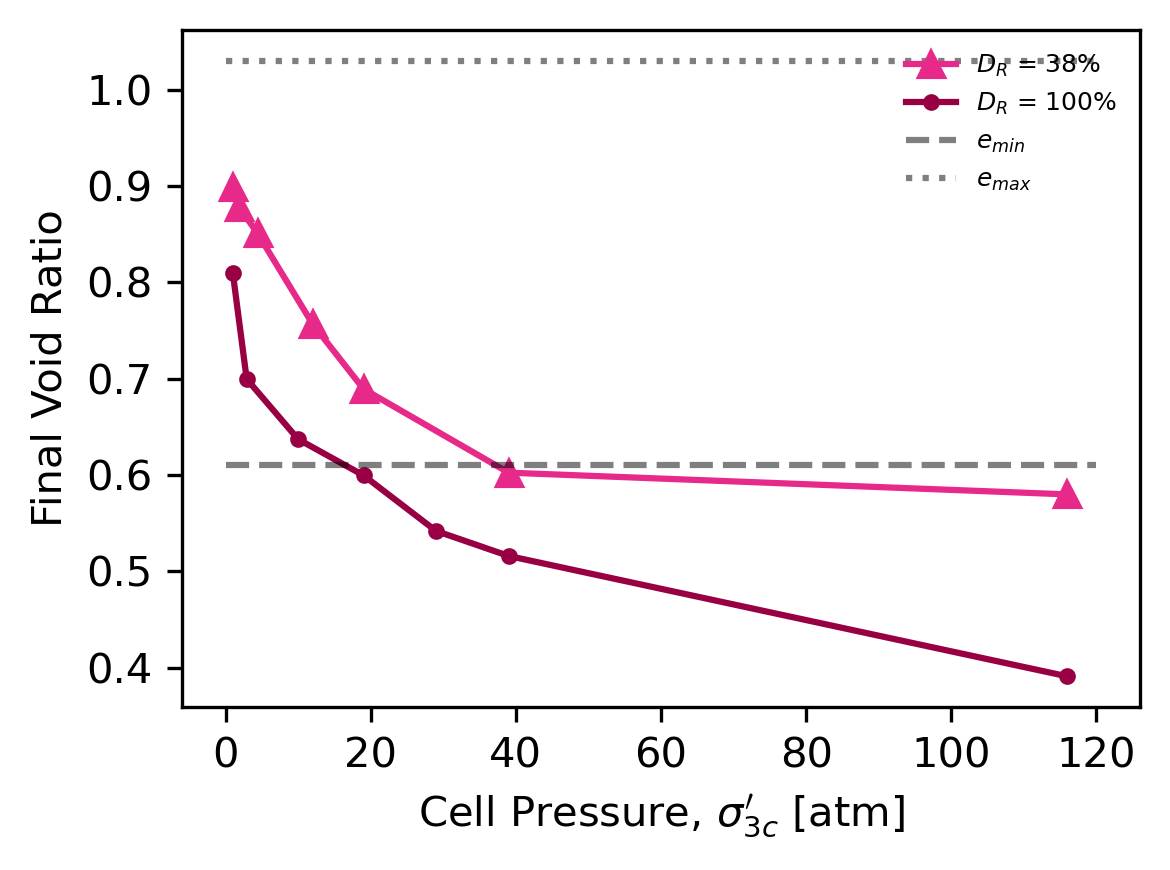

In [ ]:
strain_vol_100 = np.genfromtxt('DR100_axialstrain-volstrain.csv', delimiter = ',', usecols={1})/100
strain_vol_38 = np.genfromtxt('DR38_axialstrain-volstrain.csv', delimiter = ',', usecols={1})/100

ic(strain_vol_100)
ic(strain_vol_38)

cell_pressure_38 = 100 * np.array([1,1.9,4.4,12,19,39,116])

ef_100 = e0_100 + (strain_vol_100 * (1+e0_100)) # i used a plus here
ef_38 = e0_38 + (strain_vol_38 * (1+e0_38)) # and here too

ic(ef_100)
ic(ef_38)

fig, ax = plt.subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.plot(cell_pressure_38/100, ef_38, '^', color = '#e7298a', linestyle = '-', label = '$D_R$ = 38%')
ax.plot(cell_pressure_100/100, ef_100, '.', color = '#980043', linestyle = '-', label = '$D_R$ = 100%')
ax.hlines(e_min, 0, 120, color = 'black', linestyle = '--', alpha = 0.5, label = "$e_{min}$")
ax.hlines(e_max, 0, 120, color = 'black', linestyle = ':', alpha = 0.5, label = "$e_{max}$")
ax.set_xlabel("Cell Pressure, $\\sigma_{3c}'$ [atm]")
ax.set_ylabel('Final Void Ratio')
ax.legend(frameon = False, fontsize = 6)

## Problem 2

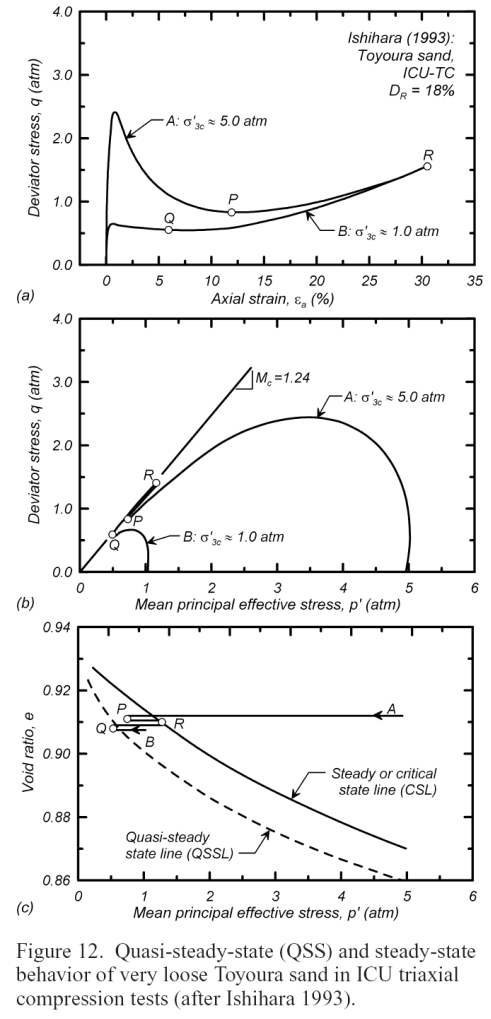